# ECO-TRI — Entraînement du modèle

Ce notebook couvre 3 compétences :
- Collecte de données
- Nettoyage de données
- Entraînement du modèle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')
print('Librairies importées !')

Librairies importées !


## Collecte de données

In [3]:
np.random.seed(42)
categories = ['plastique', 'verre', 'papier', 'carton', 'metal', 'organique']
params = {
    'plastique':  dict(poids=(0.05, 0.02), transp=(0.7, 0.2), rigid=(0.4, 0.1), recyclable=0.9),
    'verre':      dict(poids=(0.35, 0.1),  transp=(0.8, 0.15),rigid=(0.95, 0.05),recyclable=1.0),
    'papier':     dict(poids=(0.08, 0.03), transp=(0.1, 0.05), rigid=(0.2, 0.1), recyclable=0.85),
    'carton':     dict(poids=(0.15, 0.05), transp=(0.05, 0.02),rigid=(0.5, 0.15),recyclable=0.9),
    'metal':      dict(poids=(0.2, 0.08),  transp=(0.0, 0.01), rigid=(0.9, 0.05),recyclable=1.0),
    'organique':  dict(poids=(0.1, 0.04),  transp=(0.0, 0.01), rigid=(0.1, 0.05),recyclable=0.3),
}
rows = []
for cat, p in params.items():
    n_cat = 167
    rows.append(pd.DataFrame({
        'categorie':    [cat] * n_cat,
        'poids_kg':     np.random.normal(p['poids'][0], p['poids'][1], n_cat).clip(0.01),
        'transparence': np.random.normal(p['transp'][0], p['transp'][1], n_cat).clip(0, 1),
        'rigidite':     np.random.normal(p['rigid'][0], p['rigid'][1], n_cat).clip(0, 1),
        'recyclable':   np.random.binomial(1, p['recyclable'], n_cat),
    }))
df = pd.concat(rows, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Dataset créé : {len(df)} déchets')
print(df['categorie'].value_counts())
df.head()

Dataset créé : 1002 déchets
categorie
carton       167
metal        167
papier       167
plastique    167
organique    167
verre        167
Name: count, dtype: int64


,categorie,poids_kg,transparence,rigidite,recyclable
0,carton,0.113737,0.052415,0.241985,1
1,metal,0.244260,0.012469,0.889390,1
2,metal,0.244651,0.000000,0.927652,1
3,carton,0.213730,0.069155,0.735236,1
4,papier,0.050808,0.107044,0.132226,1


## Nettoyage des données

In [4]:
print('Valeurs manquantes AVANT :')
print(df.isnull().sum())
for col in ['poids_kg', 'transparence', 'rigidite']:
    mask = np.random.random(len(df)) < 0.05
    df.loc[mask, col] = np.nan
print('\nValeurs manquantes ajoutées (5%) :')
print(df.isnull().sum())
for col in ['poids_kg', 'transparence', 'rigidite']:
    df[col] = df.groupby('categorie')[col].transform(lambda x: x.fillna(x.median()))
print('\nValeurs manquantes APRÈS nettoyage :')
print(df.isnull().sum())
df.to_csv('../data/dechets_nettoyes.csv', index=False)
print('Dataset nettoyé sauvegardé !')

Valeurs manquantes AVANT :
categorie       0
poids_kg        0
transparence    0
rigidite        0
recyclable      0
dtype: int64

Valeurs manquantes ajoutées (5%) :
categorie        0
poids_kg        44
transparence    39
rigidite        57
recyclable       0
dtype: int64

Valeurs manquantes APRÈS nettoyage :
categorie       0
poids_kg        0
transparence    0
rigidite        0
recyclable      0
dtype: int64
Dataset nettoyé sauvegardé !


## Visualisation des données

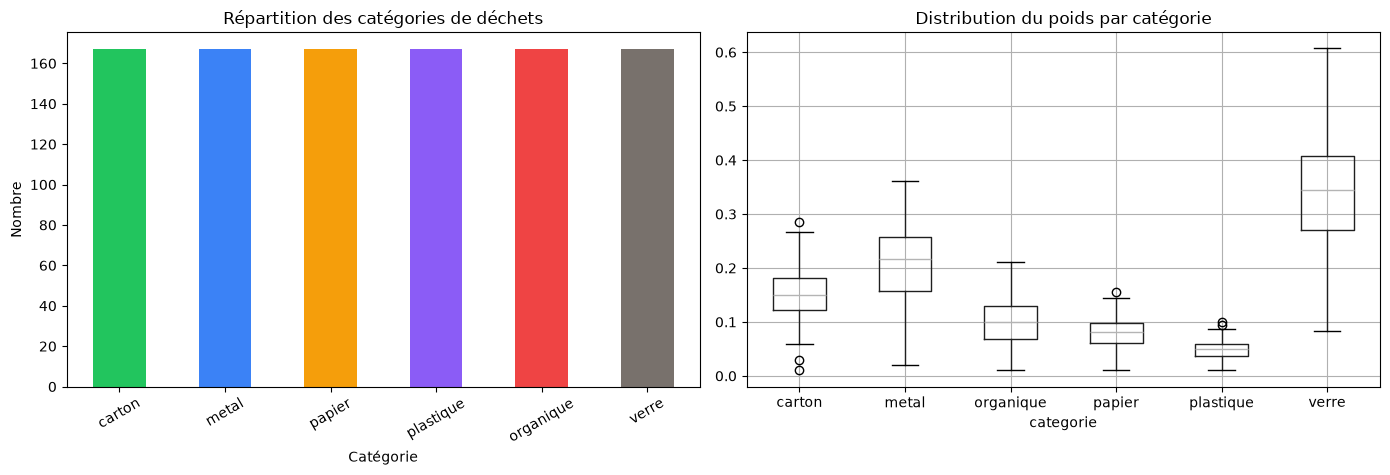

Graphiques sauvegardés !


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#22c55e','#3b82f6','#f59e0b','#8b5cf6','#ef4444','#78716c']
df['categorie'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Répartition des catégories de déchets')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=30)
df.boxplot(column='poids_kg', by='categorie', ax=axes[1])
axes[1].set_title('Distribution du poids par catégorie')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../docs/viz_donnees.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphiques sauvegardés !')

## Entraînement du modèle

In [6]:
features = ['poids_kg', 'transparence', 'rigidite', 'recyclable']
X = df[features]
y = df['categorie']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Précision du modèle : {accuracy * 100:.1f}%')
print(classification_report(y_test, y_pred))

Précision du modèle : 94.5%
              precision    recall  f1-score   support

      carton       0.84      0.94      0.89        33
       metal       1.00      0.94      0.97        33
   organique       1.00      0.94      0.97        34
      papier       0.86      0.88      0.87        34
   plastique       1.00      0.97      0.99        34
       verre       1.00      1.00      1.00        33

    accuracy                           0.95       201
   macro avg       0.95      0.95      0.95       201
weighted avg       0.95      0.95      0.95       201



## Sauvegarde du modèle

In [7]:
import pickle, os
os.makedirs('../backend/models', exist_ok=True)
with open('../backend/models/model_eco_tri.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': features}, f)
print(f'Modèle sauvegardé ! Précision : {accuracy * 100:.1f}%')
print('Le modèle est prêt !')

Modèle sauvegardé ! Précision : 94.5%
Le modèle est prêt !
